# Kalpitiya Deforestation Analysis
### Landsat 8 & 9 — Surface Reflectance — 2016 to 2025

**Study area:** Kalpitiya Peninsula, Sri Lanka (8.2369°N, 79.7628°E)

This notebook walks through a full deforestation analysis using USGS Landsat Collection 2 Level-2 data. The scenes here are large — roughly 7700 × 7600 pixels each — so the notebook is designed around a strict rule: **only one scene lives in RAM at a time**. Every intermediate result is saved to disk and reloaded when needed, so memory use stays flat no matter how many scenes you have.

The pipeline runs in six sequential passes:

| Pass | What it does | Output |
|---|---|---|
| 1 | Preprocess (cloud mask + scale + save) | `outputs/stacked/*.tif` |
| 2 | Spectral indices (NDVI, NDWI, NDBI…) | `outputs/ndvi/*.tif` etc. |
| 3 | Train Random Forest classifier | `outputs/models/*.pkl` |
| 4 | Classify every scene | `outputs/classmaps/*.tif` |
| 5 | Change detection | `outputs/change/*.tif` |
| 6 | Trend analysis and forecast | `outputs/stats/*.csv` |

If you previously ran this notebook and the stacked TIFs already exist, the preprocessing pass will skip those scenes automatically.


---
## 1. Setup

In [12]:
import subprocess, sys

def install_if_missing(package_name, import_name=None):
    import_name = import_name or package_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])

for pkg, imp in [("rasterio", "rasterio"), ("scikit-learn", "sklearn"),
                  ("seaborn", "seaborn"), ("joblib", "joblib")]:
    install_if_missing(pkg, imp)

print("All packages available.")


All packages available.


In [13]:
import os, re, gc, json, time, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import rasterio
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, r2_score, mean_squared_error)
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})

print(f"numpy    {np.__version__}")
print(f"rasterio {rasterio.__version__}")


numpy    2.3.5
rasterio 1.4.4


---
## 2. Configuration

**`RAW_DIR`** — point this at your `data/raw` folder.

**`DOWNSAMPLE`** — this is the most important memory knob. Your scenes are 7761×7611 pixels. At full resolution one 7-band float32 stack is about 1.6 GB. The table below shows what you actually get:

| DOWNSAMPLE | Scene dimensions | Stack size | Recommended for |
|---|---|---|---|
| 1 | 7761 × 7611 | ~1.6 GB | Final publication run |
| 2 | 3880 × 3805 | ~415 MB | Normal analysis |
| 3 | 2587 × 2537 | ~185 MB | Quick exploration |
| 4 | 1940 × 1903 | ~105 MB | Very fast testing |

**Start with `DOWNSAMPLE = 2`.** You still get 30-metre × 2 = 60-metre effective resolution, which is more than enough for land cover mapping at this scale. Switch to `1` for your final run if you need full resolution outputs.


In [14]:
# ── Change these two lines to match your setup ─────────────────────────────
RAW_DIR    = "data/raw"
OUT_DIR    = "outputs"
DOWNSAMPLE = 2       # see table above — start with 2, switch to 1 for final run

# ── Landsat Collection 2 Level-2 scaling ────────────────────────────────────
# DN → Surface Reflectance:  SR = DN × 0.0000275 + (−0.2)
SCALE  = 0.0000275
OFFSET = -0.2

# ── QA_PIXEL bit flags (from the L2 product guide) ──────────────────────────
QA_FILL   = 0x0001   # fill / no data
QA_DILCLD = 0x0002   # dilated cloud
QA_CIRRUS = 0x0004   # cirrus
QA_CLOUD  = 0x0008   # cloud
QA_SHADOW = 0x0010   # cloud shadow

# ── Class definitions ────────────────────────────────────────────────────────
CLASS_NAMES  = {0: "Water", 1: "Vegetation", 2: "Bare Soil", 3: "Built-Up / Scrub"}
CLASS_COLORS = {-1: "#cccccc", 0: "#2171b5", 1: "#238b45", 2: "#d4a843", 3: "#cb181d"}

VEG_THRESHOLD = 0.25   # NDVI above this is counted as vegetated

# ── Create output folder structure ──────────────────────────────────────────
for sub in ["stacked", "ndvi", "ndwi", "ndbi", "classmaps",
            "change", "graphs", "stats", "models"]:
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)

print(f"Raw dir   : {os.path.abspath(RAW_DIR)}")
print(f"Output    : {os.path.abspath(OUT_DIR)}")
print(f"Downsample: {DOWNSAMPLE}x  →  approx. {7761//DOWNSAMPLE} × {7611//DOWNSAMPLE} px per scene")


Raw dir   : d:\Projects\GitHub\terraShiftSriLanka\data\raw
Output    : d:\Projects\GitHub\terraShiftSriLanka\outputs
Downsample: 2x  →  approx. 3880 × 3805 px per scene


---
## 3. Scene Discovery

Reads the folder names and filenames to build a scene catalogue.
Nothing is loaded into memory here — we're just collecting file paths.


In [15]:
def parse_landsat_name(fname):
    """
    Extract metadata from a Landsat Collection 2 filename.
    Returns a dict, or None if the name doesn't match the pattern.

    Example: LC08_L2SP_142054_20160203_20200907_02_T1_SR_B4.TIF
    """
    base    = os.path.basename(fname)
    pattern = (r"(LC0[89])_L2SP_(\d{6})_(\d{8})_\d{8}_\d{2}_T\d_"
               r"(SR_B[1-7]|QA_PIXEL|QA_RADSAT|SR_QA_AEROSOL)")
    m = re.match(pattern, base, re.IGNORECASE)
    if not m:
        return None
    acq = m.group(3)
    return {
        "sensor":   m.group(1).upper(),
        "path_row": m.group(2),
        "date":     datetime.strptime(acq, "%Y%m%d"),
        "band":     m.group(4).upper(),
        "label":    f"{acq[:4]}_{acq[4:6]}",
    }


def discover_scenes(raw_dir):
    raw_path = Path(raw_dir)
    if not raw_path.exists():
        raise FileNotFoundError(f"Could not find: {raw_dir}")

    scenes = {}
    for folder in sorted(raw_path.iterdir()):
        if not folder.is_dir():
            continue
        label = folder.name
        tifs  = sorted(list(folder.glob("*.TIF")) + list(folder.glob("*.tif")))
        if not tifs:
            print(f"  {label}: no TIF files — skipping")
            continue

        entry = {}
        for tif in tifs:
            info = parse_landsat_name(tif.name)
            if info:
                entry[info["band"]] = str(tif)
                if "_meta" not in entry:
                    entry["_meta"] = {k: v for k, v in info.items() if k != "band"}

        if entry:
            sr_count = sum(1 for k in entry if k.startswith("SR_B"))
            has_qa   = "QA_PIXEL" in entry
            meta     = entry["_meta"]
            date_str = meta["date"].strftime("%Y-%m-%d")
            print(f"  {label}  {meta['sensor']}  {date_str}  "
                  f"{sr_count}/7 bands  QA: {'yes' if has_qa else 'MISSING'}")
            scenes[label] = entry

    print(f"{len(scenes)} scenes found.")
    return scenes


print(f"Scanning {os.path.abspath(RAW_DIR)} ...")
SCENES = discover_scenes(RAW_DIR)
LABELS = sorted(SCENES.keys())


Scanning d:\Projects\GitHub\terraShiftSriLanka\data\raw ...
  2016_02  LC08  2016-02-03  7/7 bands  QA: yes
  2016_03  LC08  2016-03-06  7/7 bands  QA: yes
  2017_02  LC08  2017-02-05  7/7 bands  QA: yes
  2017_03  LC08  2017-03-25  7/7 bands  QA: yes
  2018_02  LC08  2018-02-08  7/7 bands  QA: yes
  2018_03  LC08  2018-03-28  7/7 bands  QA: yes
  2019_02  LC08  2019-02-11  7/7 bands  QA: yes
  2019_03  LC08  2019-03-15  7/7 bands  QA: yes
  2020_02  LC08  2020-02-14  7/7 bands  QA: yes
  2020_03  LC08  2020-03-01  7/7 bands  QA: yes
  2021_02  LC08  2021-02-16  7/7 bands  QA: yes
  2021_03  LC08  2021-03-04  7/7 bands  QA: yes
  2022_02  LC09  2022-02-27  7/7 bands  QA: yes
  2022_03  LC08  2022-03-23  7/7 bands  QA: yes
  2023_02  LC09  2023-02-14  7/7 bands  QA: yes
  2023_03  LC09  2023-03-18  7/7 bands  QA: yes
  2024_02  LC09  2024-02-17  7/7 bands  QA: yes
  2024_03  LC09  2024-03-04  7/7 bands  QA: yes
  2025_02  LC09  2025-02-03  7/7 bands  QA: yes
  2025_03  LC09  2025-03-07 

  Label Sensor       Date  SR Bands Has QA
2016_02   LC08 2016-02-03         7    yes
2016_03   LC08 2016-03-06         7    yes
2017_02   LC08 2017-02-05         7    yes
2017_03   LC08 2017-03-25         7    yes
2018_02   LC08 2018-02-08         7    yes
2018_03   LC08 2018-03-28         7    yes
2019_02   LC08 2019-02-11         7    yes
2019_03   LC08 2019-03-15         7    yes
2020_02   LC08 2020-02-14         7    yes
2020_03   LC08 2020-03-01         7    yes
2021_02   LC08 2021-02-16         7    yes
2021_03   LC08 2021-03-04         7    yes
2022_02   LC09 2022-02-27         7    yes
2022_03   LC08 2022-03-23         7    yes
2023_02   LC09 2023-02-14         7    yes
2023_03   LC09 2023-03-18         7    yes
2024_02   LC09 2024-02-17         7    yes
2024_03   LC09 2024-03-04         7    yes
2025_02   LC09 2025-02-03         7    yes
2025_03   LC09 2025-03-07         7    yes


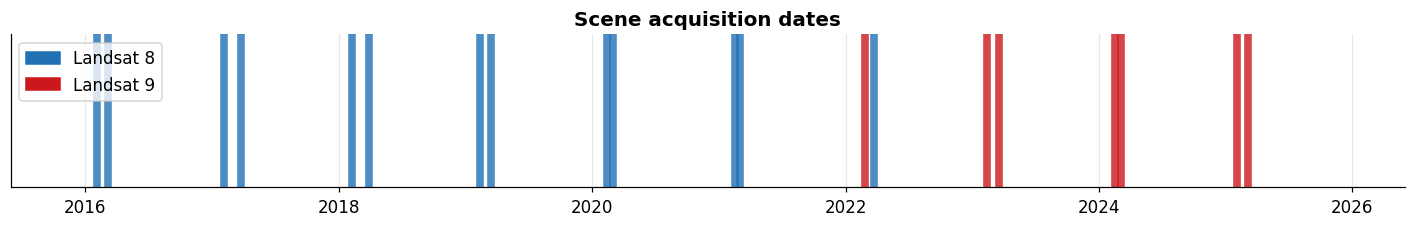

In [16]:
# Scene inventory table + timeline plot

rows = []
for lbl in LABELS:
    meta = SCENES[lbl]["_meta"]
    rows.append({
        "Label": lbl, "Sensor": meta["sensor"],
        "Date": meta["date"].strftime("%Y-%m-%d"),
        "SR Bands": sum(1 for k in SCENES[lbl] if k.startswith("SR_B")),
        "Has QA": "yes" if "QA_PIXEL" in SCENES[lbl] else "NO",
    })

df_inv = pd.DataFrame(rows)
print(df_inv.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 2.2))
sensor_colors = {"LC08": "#2171b5", "LC09": "#cb181d"}
for _, r in df_inv.iterrows():
    c = sensor_colors.get(r["Sensor"], "gray")
    try:
        ax.axvline(pd.to_datetime(r["Date"]), color=c, lw=5, alpha=0.8)
    except Exception:
        pass
ax.legend(handles=[mpatches.Patch(color="#2171b5", label="Landsat 8"),
                    mpatches.Patch(color="#cb181d", label="Landsat 9")], loc="upper left")
ax.set_title("Scene acquisition dates", fontweight="bold")
ax.yaxis.set_visible(False)
try:
    ax.set_xlim(pd.Timestamp("2015-06-01"), pd.Timestamp("2026-06-01"))
except Exception:
    pass
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/01_timeline.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 4. Preprocessing — One Scene at a Time

This is where the memory strategy matters most. Instead of loading all scenes and keeping them in a dictionary, we loop through each one, do the work, **save the result to disk, then immediately free the memory** before moving to the next scene.

By the end of this cell, `outputs/stacked/` will contain one cloud-masked GeoTIFF per scene. All later steps read from those files rather than from RAM.

If you re-run this cell, scenes whose stacked TIF already exists are skipped automatically — so you only pay the loading cost once.


In [17]:
def load_band(path, downsample=1):
    """Load one SR band, apply Collection 2 scaling, return float32 array."""
    with rasterio.open(path) as src:
        if downsample == 1:
            arr     = src.read(1).astype(np.float32)
            profile = src.profile.copy()
        else:
            out_h = src.height // downsample
            out_w = src.width  // downsample
            arr   = src.read(
                1, out_shape=(1, out_h, out_w),
                resampling=rasterio.enums.Resampling.bilinear
            )[0].astype(np.float32)
            t   = src.transform
            new_t = t * t.scale(src.width / out_w, src.height / out_h)
            profile = src.profile.copy()
            profile.update(height=out_h, width=out_w, transform=new_t)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    # Scale to surface reflectance and clip
    arr = np.clip(arr * SCALE + OFFSET, 0.0, 1.0)
    return arr, profile


def load_qa(path, downsample=1):
    """Load QA_PIXEL, return boolean mask where True = bad pixel."""
    with rasterio.open(path) as src:
        if downsample == 1:
            qa = src.read(1).astype(np.uint16)
        else:
            out_h = src.height // downsample
            out_w = src.width  // downsample
            qa    = src.read(
                1, out_shape=(1, out_h, out_w),
                resampling=rasterio.enums.Resampling.nearest
            )[0].astype(np.uint16)
    return ((qa & QA_FILL) | (qa & QA_CLOUD) | (qa & QA_DILCLD) |
            (qa & QA_SHADOW) | (qa & QA_CIRRUS)).astype(bool)


def save_raster(arr, profile, path):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    p = profile.copy()
    p.update(count=arr.shape[0], dtype="float32",
             driver="GTiff", compress="lzw", nodata=float("nan"),
             BIGTIFF="YES")  # needed for files > 4 GB
    with rasterio.open(path, "w", **p) as dst:
        dst.write(arr.astype(np.float32))


print("I/O helpers defined.")


I/O helpers defined.


In [18]:
# ── Pass 1: preprocess every scene and save to disk ─────────────────────────
# Peak RAM during this loop: one scene at a time (~1.6 GB at DS=1, ~415 MB at DS=2)

print(f"Starting preprocessing pass  (DOWNSAMPLE={DOWNSAMPLE}) ...")
cloud_log = {}   # just a small dict of percentages, not the arrays

for label in LABELS:
    out_path = f"{OUT_DIR}/stacked/{label}_stack.tif"

    # Skip if already done
    if os.path.exists(out_path):
        print(f"  {label}  already exists, skipping.")
        # Still need the cloud % for plots later — read from a sidecar if saved
        sidecar = f"{OUT_DIR}/stacked/{label}_cloud.txt"
        cloud_log[label] = float(open(sidecar).read()) if os.path.exists(sidecar) else 0.0
        continue

    t0    = time.time()
    scene = SCENES[label]
    bands = []
    profile = None

    # Load bands one at a time — each one is freed as soon as it's in the list
    for i in range(1, 8):
        arr, prof = load_band(scene[f"SR_B{i}"], downsample=DOWNSAMPLE)
        bands.append(arr)
        del arr       # free immediately
        if profile is None:
            profile = prof

    # Stack into (7, H, W)
    stack = np.stack(bands, axis=0)
    del bands
    gc.collect()

    # Cloud mask
    cloud_pct = 0.0
    if "QA_PIXEL" in scene:
        bad_px    = load_qa(scene["QA_PIXEL"], downsample=DOWNSAMPLE)
        cloud_pct = 100.0 * bad_px.sum() / bad_px.size
        stack[:, bad_px] = np.nan
        del bad_px

    # Save to disk
    save_raster(stack, profile, out_path)
    cloud_log[label] = cloud_pct

    # Save cloud % as a tiny sidecar so we can skip re-loading next time
    with open(f"{OUT_DIR}/stacked/{label}_cloud.txt", "w") as f:
        f.write(str(cloud_pct))

    h, w   = stack.shape[1], stack.shape[2]
    mem_mb = stack.nbytes / 1e6
    del stack      # ← most important line: free the 400 MB–1.6 GB array NOW
    gc.collect()

    print(f"  {label}  {h}x{w}px  cloud={cloud_pct:.1f}%  "
          f"{mem_mb:.0f} MB  ({time.time()-t0:.1f}s)  → saved")

print(f"Done. All stacked TIFs in {OUT_DIR}/stacked/")


Starting preprocessing pass  (DOWNSAMPLE=2) ...


IndexError: tuple index out of range

In [ ]:
# Cloud cover bar — built from the small cloud_log dict, not the rasters

fig, ax = plt.subplots(figsize=(13, 3.5))
bar_colors = ["#238b45" if v < 30 else "#d4a843" if v < 60 else "#cb181d"
               for v in cloud_log.values()]
ax.bar(list(cloud_log.keys()), list(cloud_log.values()),
       color=bar_colors, edgecolor="white", width=0.65)
ax.axhline(30, color="#666", ls="--", lw=1.2, label="30% threshold")
ax.set_ylabel("Cloud cover (%)")
ax.set_title("Cloud cover per scene  (green < 30% / orange 30–60% / red > 60%)",
              fontweight="bold")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/02_cloud_cover.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
# RGB preview grid — load one scene at a time, plot it, then free the array.
# We never hold more than one scene in memory at this point.

def pct_stretch(arr, lo=2, hi=98):
    p_lo = np.nanpercentile(arr, lo)
    p_hi = np.nanpercentile(arr, hi)
    return np.clip((arr - p_lo) / (p_hi - p_lo + 1e-9), 0.0, 1.0)


ncols = 3
nrows = (len(LABELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.2))
axes = np.array(axes).ravel()

for i, label in enumerate(LABELS):
    stk_path = f"{OUT_DIR}/stacked/{label}_stack.tif"
    if not os.path.exists(stk_path):
        axes[i].set_title(f"{label} — missing"); axes[i].axis("off")
        continue

    with rasterio.open(stk_path) as src:
        # Read only bands 2, 3, 4 (indices 2, 3, 4 in the file = B3, B4, B5)
        # File band order: B1=1, B2=2, B3=3, B4=4, B5=5, B6=6, B7=7
        r = src.read(4).astype(np.float32)   # B4 red
        g = src.read(3).astype(np.float32)   # B3 green
        b = src.read(2).astype(np.float32)   # B2 blue

    rgb = np.stack([pct_stretch(r), pct_stretch(g), pct_stretch(b)], axis=-1)
    del r, g, b
    gc.collect()

    axes[i].imshow(rgb)
    axes[i].set_title(f"True colour — {label}", fontsize=9, fontweight="bold")
    axes[i].axis("off")
    del rgb
    gc.collect()

for j in range(len(LABELS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("True Colour Composites (cloud-masked, scaled)",
              fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/02_rgb_grid.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 5. Spectral Indices

We compute NDVI, NDWI, NDBI, NBR, and EVI for each scene. Each scene is loaded from its stacked TIF, the five index arrays are computed, **each index is saved immediately to its own TIF**, and then everything is freed.

We also collect summary statistics (mean, std, percentiles) into a small DataFrame — that stays in memory because it's tiny (just numbers, not raster arrays).


In [ ]:
def safe_ratio(a, b):
    """(a - b) / (a + b) — returns NaN where denominator is near zero."""
    with np.errstate(invalid="ignore", divide="ignore"):
        denom = a.astype(np.float32) + b.astype(np.float32)
        return np.where(np.abs(denom) > 1e-9,
                        (a.astype(np.float32) - b.astype(np.float32)) / denom,
                        np.nan).astype(np.float32)


def compute_indices(stack):
    """
    Compute NDVI, NDWI, NDBI, NBR, EVI from a 7-band stack.
    Band order in the file: B1(0), B2(1), B3(2), B4(3), B5(4), B6(5), B7(6)
    """
    blue  = stack[1];  green = stack[2];  red   = stack[3]
    nir   = stack[4];  swir1 = stack[5];  swir2 = stack[6]

    ndvi = np.clip(safe_ratio(nir,   red),   -1.0, 1.0)
    ndwi = np.clip(safe_ratio(green, nir),   -1.0, 1.0)
    ndbi = np.clip(safe_ratio(swir1, nir),   -1.0, 1.0)
    nbr  = np.clip(safe_ratio(nir,   swir2), -1.0, 1.0)

    with np.errstate(invalid="ignore", divide="ignore"):
        denom_evi = nir + 6.0 * red - 7.5 * blue + 1.0
        evi = np.where(np.abs(denom_evi) > 1e-9,
                       2.5 * (nir - red) / denom_evi, np.nan).astype(np.float32)
    evi = np.clip(evi, -1.0, 1.0)

    return {"ndvi": ndvi, "ndwi": ndwi, "ndbi": ndbi, "nbr": nbr, "evi": evi}


print("Index functions defined.")


In [ ]:
# ── Pass 2: compute and save indices, one scene at a time ───────────────────
# Peak RAM: one scene stack (~415 MB at DS=2) + five index arrays
# (~5 × 60 MB at DS=2) = ~700 MB total. Freed after each scene.

print("Computing spectral indices...")
stats_rows = []   # just numbers — stays in memory permanently (tiny)

for label in LABELS:
    stk_path = f"{OUT_DIR}/stacked/{label}_stack.tif"
    if not os.path.exists(stk_path):
        print(f"  {label}: stacked TIF missing — run preprocessing first")
        continue

    t0 = time.time()

    # Load the stacked TIF we saved in the previous pass
    with rasterio.open(stk_path) as src:
        stack   = src.read().astype(np.float32)   # (7, H, W)
        profile = src.profile.copy()

    idx = compute_indices(stack)
    del stack   # free the ~415 MB stack immediately
    gc.collect()

    # Save each index to its own TIF, then free it
    one_band_profile = profile.copy()
    one_band_profile.update(count=1, dtype="float32",
                             compress="lzw", nodata=float("nan"))

    for iname, arr in idx.items():
        out_path = f"{OUT_DIR}/{iname}/{label}_{iname}.tif"
        if os.path.exists(out_path):
            continue  # already saved from a previous run
        save_raster(arr, one_band_profile, out_path)

    # Collect statistics while the arrays are still in memory
    ndvi_valid = idx["ndvi"][~np.isnan(idx["ndvi"])].ravel()
    if len(ndvi_valid) > 1000:
        yr, mo = int(label[:4]), int(label[5:])
        stats_rows.append({
            "label":        label,
            "year":         yr, "month": mo,
            "date_frac":    yr + (mo - 1) / 12,
            "mean_ndvi":    float(ndvi_valid.mean()),
            "std_ndvi":     float(ndvi_valid.std()),
            "median_ndvi":  float(np.median(ndvi_valid)),
            "p10":          float(np.percentile(ndvi_valid, 10)),
            "p90":          float(np.percentile(ndvi_valid, 90)),
            "mean_ndwi":    float(np.nanmean(idx["ndwi"])),
            "mean_ndbi":    float(np.nanmean(idx["ndbi"])),
            "pct_dense":    float(100.0 * (ndvi_valid > 0.50).mean()),
            "pct_moderate": float(100.0 * ((ndvi_valid > 0.25) & (ndvi_valid <= 0.50)).mean()),
            "pct_sparse":   float(100.0 * ((ndvi_valid > 0.00) & (ndvi_valid <= 0.25)).mean()),
            "pct_nonveg":   float(100.0 * (ndvi_valid <= 0.00).mean()),
            "n_valid_px":   int(len(ndvi_valid)),
        })

    mn = np.nanmean
    print(f"  {label}  NDVI={mn(idx['ndvi']):+.4f}  "
          f"NDWI={mn(idx['ndwi']):+.4f}  NDBI={mn(idx['ndbi']):+.4f}  "
          f"({time.time()-t0:.1f}s)")

    del idx, ndvi_valid   # free index arrays
    gc.collect()

# Save the statistics DataFrame — it's just numbers so keeping it is fine
df_ts = pd.DataFrame(stats_rows).sort_values("date_frac").reset_index(drop=True)
df_ts.to_csv(f"{OUT_DIR}/stats/index_statistics.csv", index=False)
print(f"Stats collected for {len(df_ts)} scenes.")


In [ ]:
# NDVI grid — load each NDVI TIF individually, plot, free, move on.
# Every image is read directly from disk so RAM stays low.

ncols = 4
nrows = (len(LABELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.3, nrows * 4.0))
axes = np.array(axes).ravel()

for i, label in enumerate(LABELS):
    ndvi_path = f"{OUT_DIR}/ndvi/{label}_ndvi.tif"
    if not os.path.exists(ndvi_path):
        axes[i].set_title(f"{label} — missing"); axes[i].axis("off")
        continue

    with rasterio.open(ndvi_path) as src:
        ndvi_arr = src.read(1).astype(np.float32)

    im = axes[i].imshow(ndvi_arr, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
    axes[i].set_title(f"NDVI  {label}", fontsize=9, fontweight="bold")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.03, shrink=0.85)

    del ndvi_arr
    gc.collect()

for j in range(len(LABELS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("NDVI — all scenes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/03_ndvi_grid.png", dpi=100, bbox_inches="tight")
plt.show()


In [ ]:
# NDVI distribution plot — subsample each scene to 300k pixels max
# so the histogram doesn't eat memory.

fig, ax = plt.subplots(figsize=(13, 5))
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(LABELS)))

for i, label in enumerate(LABELS):
    ndvi_path = f"{OUT_DIR}/ndvi/{label}_ndvi.tif"
    if not os.path.exists(ndvi_path):
        continue
    with rasterio.open(ndvi_path) as src:
        arr = src.read(1).astype(np.float32)

    valid = arr[~np.isnan(arr)].ravel()
    del arr
    gc.collect()

    # Subsample — 300k points gives smooth histograms without hogging RAM
    if len(valid) > 300_000:
        valid = np.random.choice(valid, 300_000, replace=False)

    ax.hist(valid, bins=150, density=True, histtype="stepfilled",
            alpha=0.45, color=palette[i], edgecolor="none",
            label=label.replace("_", "/"))
    del valid

ax.axvline(VEG_THRESHOLD, color="black", ls="--", lw=1.5,
            label=f"Veg threshold ({VEG_THRESHOLD})")
ax.set_xlabel("NDVI"); ax.set_ylabel("Density")
ax.set_title("NDVI distributions — all scenes"
              "A left shift over time = vegetation decline", fontweight="bold")
ax.legend(ncol=4, fontsize=8)
ax.set_xlim(-0.25, 0.85)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/03_ndvi_distributions.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 6. Land Cover Classification

**Pass 3 — Train:** Load the reference scene once to generate pseudo-labels and train the Random Forest. Free everything when done.

**Pass 4 — Classify:** Loop through every scene, load it from disk, predict, save the classified map, free.

Peak RAM during training: one scene stack + feature matrix (~800 MB at DS=2).  
Peak RAM during inference: one scene at a time (~700 MB at DS=2).


In [ ]:
def pseudo_labels(ndvi_flat, ndwi_flat, ndbi_flat):
    """
    Label high-confidence pixels using spectral thresholds.
    Returns int8 array — -1 means 'not confident enough to label'.
    Classes: 0=Water, 1=Vegetation, 2=Bare Soil, 3=Built-Up/Scrub
    """
    lab = np.full(len(ndvi_flat), -1, dtype=np.int8)
    lab[(ndvi_flat > 0.05)  & (ndvi_flat < 0.22) & (np.abs(ndbi_flat) < 0.12)] = 2
    lab[(ndbi_flat > 0.08)  & (ndvi_flat < 0.12)]                               = 3
    lab[(ndwi_flat > 0.15)  & (ndvi_flat < 0.02)]                               = 0
    lab[(ndvi_flat > 0.32)  & (ndwi_flat < -0.05)]                              = 1
    return lab


def build_features(stack, ndvi, ndwi, ndbi, nbr, evi):
    """
    Build (N_valid_pixels, 11) feature matrix from one scene.
    Frees the index arrays from memory after use — pass them in,
    they'll be consumed.
    """
    layers = [stack[1], stack[2], stack[3],   # B2 B3 B4
               stack[4], stack[5], stack[6],   # B5 B6 B7
               ndvi, ndwi, ndbi, nbr, evi]
    cube       = np.stack(layers, axis=0)      # (11, H, W)
    valid_mask = ~np.any(np.isnan(cube), axis=0)
    X          = cube.reshape(11, -1).T[valid_mask.ravel()]
    del cube
    return X, valid_mask


FEATURE_NAMES = ["B2","B3","B4","B5","B6","B7","NDVI","NDWI","NDBI","NBR","EVI"]
print("Classification helpers ready.")


In [ ]:
# ── Pass 3: Train on the earliest scene ─────────────────────────────────────
ref_label = LABELS[0]
print(f"Training on reference scene: {ref_label}")

# Load stack
with rasterio.open(f"{OUT_DIR}/stacked/{ref_label}_stack.tif") as src:
    ref_stack = src.read().astype(np.float32)

# Load indices (already saved as individual TIFs)
def read_index(label, name):
    with rasterio.open(f"{OUT_DIR}/{name}/{label}_{name}.tif") as src:
        return src.read(1).astype(np.float32)

r_ndvi = read_index(ref_label, "ndvi")
r_ndwi = read_index(ref_label, "ndwi")
r_ndbi = read_index(ref_label, "ndbi")
r_nbr  = read_index(ref_label, "nbr")
r_evi  = read_index(ref_label, "evi")

X_all, vmask = build_features(ref_stack, r_ndvi, r_ndwi, r_ndbi, r_nbr, r_evi)
del ref_stack, r_nbr, r_evi
gc.collect()

# Pseudo-label
labs = pseudo_labels(r_ndvi[vmask], r_ndwi[vmask], r_ndbi[vmask])
del r_ndvi, r_ndwi, r_ndbi, vmask
gc.collect()

# Keep only labelled pixels
mask_lab = labs >= 0
X_lab    = X_all[mask_lab]
y_lab    = labs[mask_lab]
del X_all, labs
gc.collect()

print(f"  Labelled pixels: {len(y_lab):,}")
for cid, cname in CLASS_NAMES.items():
    n = int((y_lab == cid).sum())
    print(f"    {cname:<22} {n:>9,}  ({100*n/len(y_lab):.1f}%)")

# Scale and split
SCALER   = StandardScaler()
X_sc     = SCALER.fit_transform(X_lab)
del X_lab
gc.collect()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_lab, test_size=0.25, stratify=y_lab, random_state=42
)
del X_sc, y_lab
gc.collect()

print(f"
  Train: {len(X_tr):,}   Test: {len(X_te):,}")
print("  Training Random Forest (200 trees, all CPU cores)...")
t0 = time.time()

RF = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced",
    oob_score=True, n_jobs=-1, random_state=42,
)
RF.fit(X_tr, y_tr)

y_pred_te = RF.predict(X_te)
print(f"  Training time : {time.time()-t0:.1f}s")
print(f"  OOB accuracy  : {RF.oob_score_:.4f}")
print(f"  Test accuracy : {accuracy_score(y_te, y_pred_te):.4f}")

# Save model
joblib.dump(RF,     f"{OUT_DIR}/models/rf_model.pkl")
joblib.dump(SCALER, f"{OUT_DIR}/models/scaler.pkl")
del X_tr, X_te
gc.collect()
print(f"
  Model saved.")


In [ ]:
# Evaluation plots — confusion matrix and feature importances

cm = confusion_matrix(y_te, y_pred_te)
print(classification_report(y_te, y_pred_te,
      target_names=[CLASS_NAMES[i] for i in range(4)]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=[CLASS_NAMES[i] for i in range(4)],
            yticklabels=[CLASS_NAMES[i] for i in range(4)], ax=axes[0])
axes[0].set_xlabel("Predicted", fontweight="bold")
axes[0].set_ylabel("Actual",    fontweight="bold")
axes[0].set_title("Confusion Matrix", fontweight="bold")

fi    = RF.feature_importances_
order = np.argsort(fi)
axes[1].barh(np.array(FEATURE_NAMES)[order], fi[order], color="#2171b5", alpha=0.8)
axes[1].set_xlabel("Mean Decrease in Impurity")
axes[1].set_title("Feature Importances", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/04_rf_evaluation.png", dpi=130, bbox_inches="tight")
plt.show()

del y_te, y_pred_te, cm
gc.collect()


In [ ]:
# ── Pass 4: classify every scene ────────────────────────────────────────────
# Load RF + scaler from disk in case the kernel was restarted since training
if "RF" not in dir() or "SCALER" not in dir():
    RF     = joblib.load(f"{OUT_DIR}/models/rf_model.pkl")
    SCALER = joblib.load(f"{OUT_DIR}/models/scaler.pkl")
    print("Loaded model from disk.")

print("Classifying all scenes...")
area_records = []

for label in LABELS:
    out_path = f"{OUT_DIR}/classmaps/{label}_classmap.tif"
    stk_path = f"{OUT_DIR}/stacked/{label}_stack.tif"

    if not os.path.exists(stk_path):
        print(f"  {label}: stacked TIF missing — skipping")
        continue

    t0 = time.time()

    # Load stack and indices
    with rasterio.open(stk_path) as src:
        stk     = src.read().astype(np.float32)
        profile = src.profile.copy()

    ndvi = read_index(label, "ndvi")
    ndwi = read_index(label, "ndwi")
    ndbi = read_index(label, "ndbi")
    nbr  = read_index(label, "nbr")
    evi  = read_index(label, "evi")

    H, W = stk.shape[1], stk.shape[2]

    X_all, vmask = build_features(stk, ndvi, ndwi, ndbi, nbr, evi)
    del stk, ndvi, ndwi, ndbi, nbr, evi
    gc.collect()

    X_sc    = SCALER.transform(X_all)
    del X_all
    gc.collect()

    # Predict in chunks to avoid large intermediate arrays
    CHUNK   = 500_000
    preds   = np.empty(X_sc.shape[0], dtype=np.int8)
    for start in range(0, len(X_sc), CHUNK):
        preds[start:start+CHUNK] = RF.predict(X_sc[start:start+CHUNK])
    del X_sc
    gc.collect()

    # Reconstruct 2D map
    cmap_flat         = np.full(H * W, -1, dtype=np.int8)
    cmap_flat[vmask.ravel()] = preds
    cmap              = cmap_flat.reshape(H, W)
    del cmap_flat, preds, vmask
    gc.collect()

    # Save
    p1 = profile.copy()
    p1.update(count=1, dtype="int8", compress="lzw", nodata=-1)
    save_raster(cmap, p1, out_path)

    # Area stats
    total_valid = int((cmap >= 0).sum())
    row = {"label": label}
    for cid, cname in CLASS_NAMES.items():
        key = cname.split("/")[0].strip().replace(" ", "_")
        n   = int((cmap == cid).sum())
        row[f"{key}_pct"] = round(100 * n / total_valid if total_valid > 0 else 0, 2)
        row[f"{key}_ha"]  = round(n * 0.09 * (DOWNSAMPLE ** 2), 1)
    area_records.append(row)

    veg_pct = row.get("Vegetation_pct", 0)
    print(f"  {label}  veg={veg_pct:.1f}%  ({time.time()-t0:.1f}s)")

    del cmap
    gc.collect()

df_areas = pd.DataFrame(area_records)
df_areas.to_csv(f"{OUT_DIR}/stats/class_areas.csv", index=False)
print(f"Class areas saved  ({len(df_areas)} scenes).")


In [ ]:
# Classification map grid + area stacked bar
# Maps are loaded from disk one at a time — no arrays are held between panels.

def draw_classmap(cmap, title, ax):
    clist  = [CLASS_COLORS[c] for c in sorted(CLASS_COLORS)]
    bounds = [c - 0.5 for c in sorted(CLASS_COLORS)] + [max(CLASS_COLORS) + 0.5]
    cmap_obj = mcolors.ListedColormap(clist)
    norm_obj = mcolors.BoundaryNorm(bounds, cmap_obj.N)
    ax.imshow(cmap, cmap=cmap_obj, norm=norm_obj, interpolation="nearest")
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.axis("off")
    patches = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c])
               for c in range(4)]
    ax.legend(handles=patches, loc="lower right", fontsize=6, framealpha=0.85)


ncols = 4
nrows = (len(LABELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.3, nrows * 4.0))
axes = np.array(axes).ravel()

for i, label in enumerate(LABELS):
    cmap_path = f"{OUT_DIR}/classmaps/{label}_classmap.tif"
    if not os.path.exists(cmap_path):
        axes[i].set_title(f"{label} — missing"); axes[i].axis("off")
        continue
    with rasterio.open(cmap_path) as src:
        cmap_arr = src.read(1).astype(np.int8)
    draw_classmap(cmap_arr, label, axes[i])
    del cmap_arr
    gc.collect()

for j in range(len(LABELS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Land Cover Classification — all scenes", fontsize=13,
              fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/04_classmaps.png", dpi=100, bbox_inches="tight")
plt.show()

# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(df_areas))
col_cfg = [("Water_pct","Water","#2171b5"),
            ("Vegetation_pct","Vegetation","#238b45"),
            ("Bare_Soil_pct","Bare Soil","#d4a843"),
            ("Built-Up_pct","Built-Up / Scrub","#cb181d")]
for col_key, lbl_c, col_c in col_cfg:
    match = next((c for c in df_areas.columns
                   if c.lower().replace(" ","_").startswith(lbl_c.lower().split()[0])
                   and c.endswith("_pct")), None)
    if match:
        vals = df_areas[match].fillna(0).values
        ax.bar(df_areas["label"], vals, bottom=bottom,
               label=lbl_c, color=col_c, edgecolor="white", width=0.65)
        bottom += vals
ax.set_ylabel("% of scene"); ax.set_xlabel("Scene date")
ax.set_title("Land cover composition over time", fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.set_ylim(0, 110)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/04_area_over_time.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 7. Change Detection

We compare NDVI images across time. The arrays are loaded from the saved NDVI TIFs on disk, so again we only ever have two scenes in memory at once.


In [ ]:
def veg_change_stats(ndvi_t1, ndvi_t2, thresh=VEG_THRESHOLD):
    """
    Compare two NDVI arrays and return vegetation change in pixels and hectares.
    Pixel area = 30m × DOWNSAMPLE × 30m × DOWNSAMPLE = 0.09 × DS² ha
    """
    px_ha = 0.09 * (DOWNSAMPLE ** 2)
    h = min(ndvi_t1.shape[0], ndvi_t2.shape[0])
    w = min(ndvi_t1.shape[1], ndvi_t2.shape[1])
    t1, t2 = ndvi_t1[:h, :w], ndvi_t2[:h, :w]
    valid  = (~np.isnan(t1)) & (~np.isnan(t2))
    v1 = (t1 > thresh) & valid
    v2 = (t2 > thresh) & valid
    n1, n2    = int(v1.sum()), int(v2.sum())
    lost      = int((v1 & ~v2).sum())
    gained    = int((~v1 & v2).sum())
    return {
        "n_veg_t1": n1, "n_veg_t2": n2,
        "lost_px": lost, "gained_px": gained,
        "lost_ha":   round(lost        * px_ha, 1),
        "gained_ha": round(gained      * px_ha, 1),
        "net_ha":    round((n2 - n1)   * px_ha, 1),
        "pct_loss":  round(100 * lost   / n1 if n1 > 0 else 0, 2),
        "pct_gain":  round(100 * gained / n1 if n1 > 0 else 0, 2),
        "pct_net":   round(100 * (n2-n1) / n1 if n1 > 0 else 0, 2),
    }


# Load earliest and latest NDVI from disk
sorted_labels = sorted(df_ts["label"].tolist()) if len(df_ts) > 0 else LABELS
T1, T2 = sorted_labels[0], sorted_labels[-1]

with rasterio.open(f"{OUT_DIR}/ndvi/{T1}_ndvi.tif") as src:
    ndvi_t1   = src.read(1).astype(np.float32)
    ref_prof  = src.profile.copy()

with rasterio.open(f"{OUT_DIR}/ndvi/{T2}_ndvi.tif") as src:
    ndvi_t2 = src.read(1).astype(np.float32)

h = min(ndvi_t1.shape[0], ndvi_t2.shape[0])
w = min(ndvi_t1.shape[1], ndvi_t2.shape[1])
diff = (ndvi_t2[:h, :w] - ndvi_t1[:h, :w]).astype(np.float32)

# Classify change: < -0.08 = loss,  > +0.08 = gain
chg = np.full_like(diff, 0, dtype=np.int8)
chg[diff < -0.08]  = -1
chg[diff >  0.08]  =  1
chg[np.isnan(diff)] = -99

vstats = veg_change_stats(ndvi_t1, ndvi_t2)

print(f"{'='*52}")
print(f"  Vegetation change  {T1}  →  {T2}")
print(f"{'='*52}")
px_ha = 0.09 * DOWNSAMPLE ** 2
print(f"  Veg area at {T1} : {vstats['n_veg_t1']:>10,} px  "
      f"({vstats['n_veg_t1']*px_ha:>10,.0f} ha)")
print(f"  Veg area at {T2} : {vstats['n_veg_t2']:>10,} px  "
      f"({vstats['n_veg_t2']*px_ha:>10,.0f} ha)")
print(f"  Area lost              : {vstats['lost_px']:>10,} px  "
      f"({vstats['lost_ha']:>8,.1f} ha)  {vstats['pct_loss']:+.2f}%")
print(f"  Area gained            : {vstats['gained_px']:>10,} px  "
      f"({vstats['gained_ha']:>8,.1f} ha)  {vstats['pct_gain']:+.2f}%")
print(f"  Net                    :  "
      f"({vstats['net_ha']:>+8,.1f} ha)  {vstats['pct_net']:+.2f}%")
print(f"  Mean ΔNDVI             : {np.nanmean(diff):>+.4f}")
print(f"{'='*52}")

with open(f"{OUT_DIR}/stats/vegetation_change.json", "w") as f:
    json.dump({**vstats, "T1": T1, "T2": T2,
               "mean_delta": round(float(np.nanmean(diff)), 4)}, f, indent=2)

# Save diff and change class TIFs
save_raster(diff, ref_prof, f"{OUT_DIR}/change/{T1}_to_{T2}_delta_ndvi.tif")
save_raster(chg.astype(np.float32), ref_prof,
            f"{OUT_DIR}/change/{T1}_to_{T2}_change_class.tif")


In [ ]:
# Change maps — three panels side by side

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

im0 = axes[0].imshow(ndvi_t1, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
axes[0].set_title(f"NDVI — {T1}", fontweight="bold"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)

im1 = axes[1].imshow(ndvi_t2, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
axes[1].set_title(f"NDVI — {T2}", fontweight="bold"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)

im2 = axes[2].imshow(diff, cmap="RdBu", vmin=-0.4, vmax=0.4)
axes[2].set_title(f"ΔNDVI  {T1} → {T2}", fontweight="bold"); axes[2].axis("off")
cb2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.03)
cb2.set_label("Positive = gain")

plt.suptitle("NDVI change detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/change/ndvi_change_maps.png", dpi=110, bbox_inches="tight")
plt.show()

# Change class map
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
chg_cmap = mcolors.ListedColormap(["#cb181d", "#f7f7f7", "#238b45"])
chg_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3)
disp     = np.where(chg == -99, np.nan, chg.astype(float))
im3 = axes[0].imshow(disp, cmap=chg_cmap, norm=chg_norm, interpolation="nearest")
axes[0].set_title(f"Change class: {T1} → {T2}", fontweight="bold"); axes[0].axis("off")
axes[0].legend(handles=[
    mpatches.Patch(color="#cb181d", label=f"Loss  ({vstats['lost_ha']:,.0f} ha)"),
    mpatches.Patch(color="#f7f7f7", label="Stable"),
    mpatches.Patch(color="#238b45", label=f"Gain  ({vstats['gained_ha']:,.0f} ha)"),
], loc="lower right", fontsize=9)

counts = [int((chg==-1).sum()), int((chg==0).sum()), int((chg==1).sum())]
bars   = axes[1].bar(["Loss","Stable","Gain"], counts,
                      color=["#cb181d","#eeeeee","#238b45"], edgecolor="#666", width=0.5)
for b, n in zip(bars, counts):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                  f"{n:,}", ha="center", fontsize=9)
axes[1].set_ylabel("Pixel count")
axes[1].set_title("Change pixel summary", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/change/change_class_map.png", dpi=110, bbox_inches="tight")
plt.show()

del ndvi_t1, ndvi_t2, diff, chg, disp
gc.collect()


In [ ]:
# Class transition matrix (only if classmap TIFs exist for both dates)

def load_classmap(label):
    path = f"{OUT_DIR}/classmaps/{label}_classmap.tif"
    if not os.path.exists(path):
        return None
    with rasterio.open(path) as src:
        return src.read(1).astype(np.int8)

cm_t1 = load_classmap(T1)
cm_t2 = load_classmap(T2)

if cm_t1 is not None and cm_t2 is not None:
    h_ = min(cm_t1.shape[0], cm_t2.shape[0])
    w_ = min(cm_t1.shape[1], cm_t2.shape[1])
    t1_f = cm_t1[:h_, :w_].ravel()
    t2_f = cm_t2[:h_, :w_].ravel()
    valid = (t1_f >= 0) & (t2_f >= 0)
    mat = np.zeros((4, 4), dtype=np.int64)
    for i in range(4):
        for j in range(4):
            mat[i, j] = int(((t1_f == i) & (t2_f == j) & valid).sum())

    class_labels = [CLASS_NAMES[i] for i in range(4)]
    df_tm = pd.DataFrame(mat, index=class_labels, columns=class_labels)
    df_tm.index.name = f"From ({T1})"; df_tm.columns.name = f"To ({T2})"
    print(f"Transition matrix ({T1} → {T2}):")
    print(df_tm.to_string())
    df_tm.to_csv(f"{OUT_DIR}/stats/transition_matrix.csv")

    # Normalise rows for colour — annotate with raw counts
    row_sums = mat.sum(axis=1, keepdims=True)
    mat_norm = np.where(row_sums > 0, mat / row_sums.astype(float), 0)
    fig, ax  = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat_norm, annot=mat, fmt=",d", cmap="YlOrRd",
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, linewidths=0.5)
    ax.set_title(f"Class transitions: {T1} → {T2}"
                  f"(colour = row fraction, numbers = pixel count)",
                  fontweight="bold")
    ax.set_xlabel(f"To ({T2})"); ax.set_ylabel(f"From ({T1})")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/change/transition_matrix.png", dpi=130, bbox_inches="tight")
    plt.show()

    del cm_t1, cm_t2, t1_f, t2_f, mat, mat_norm
    gc.collect()


In [ ]:
# Sequential pair analysis — loads two NDVI TIFs at a time, frees immediately

pair_rows  = []
diff_stack = []   # small list of diff arrays for hotspot map

for i in range(len(sorted_labels) - 1):
    l1, l2 = sorted_labels[i], sorted_labels[i+1]
    p1 = f"{OUT_DIR}/ndvi/{l1}_ndvi.tif"
    p2 = f"{OUT_DIR}/ndvi/{l2}_ndvi.tif"
    if not (os.path.exists(p1) and os.path.exists(p2)):
        continue

    with rasterio.open(p1) as src: n1 = src.read(1).astype(np.float32)
    with rasterio.open(p2) as src: n2 = src.read(1).astype(np.float32)

    h_ = min(n1.shape[0], n2.shape[0]); w_ = min(n1.shape[1], n2.shape[1])
    d  = (n2[:h_, :w_] - n1[:h_, :w_]).astype(np.float32)
    diff_stack.append(d.copy())

    vs = veg_change_stats(n1, n2)
    pair_rows.append({"from": l1, "to": l2,
                       "mean_delta": round(float(np.nanmean(d)), 5), **vs})
    print(f"  {l1} → {l2}   Δ={np.nanmean(d):+.4f}   "
          f"lost={vs['lost_ha']:.0f} ha   gained={vs['gained_ha']:.0f} ha")

    del n1, n2, d
    gc.collect()

df_pairs = pd.DataFrame(pair_rows)
df_pairs.to_csv(f"{OUT_DIR}/stats/sequential_change.csv", index=False)

# Summary chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plabels   = [f"{r['from'][-5:]}" for _, r in df_pairs.iterrows()]
bar_c     = ["#cb181d" if v < 0 else "#238b45" for v in df_pairs["mean_delta"]]
axes[0].bar(range(len(plabels)), df_pairs["mean_delta"], color=bar_c, edgecolor="white")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(range(len(plabels)))
axes[0].set_xticklabels(plabels, rotation=40, ha="right", fontsize=8)
axes[0].set_ylabel("Mean ΔNDVI"); axes[0].set_title("NDVI change per period", fontweight="bold")

x = np.arange(len(plabels)); w = 0.38
axes[1].bar(x-w/2, df_pairs["lost_ha"],   width=w, color="#cb181d", label="Lost (ha)")
axes[1].bar(x+w/2, df_pairs["gained_ha"], width=w, color="#238b45", label="Gained (ha)")
axes[1].set_xticks(x); axes[1].set_xticklabels(plabels, rotation=40, ha="right", fontsize=8)
axes[1].set_ylabel("Area (ha)"); axes[1].set_title("Vegetation area change per period", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/change/sequential_change.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
# Hotspot map: how many periods had ΔNDVI < -0.08 at each pixel?
if diff_stack:
    ref = diff_stack[0]
    hotspot = np.zeros(ref.shape, dtype=np.uint8)
    for d in diff_stack:
        h_ = min(ref.shape[0], d.shape[0]); w_ = min(ref.shape[1], d.shape[1])
        hotspot[:h_, :w_] += (d[:h_, :w_] < -0.08).astype(np.uint8)
    del diff_stack, ref
    gc.collect()

    n_periods = len(pair_rows)
    fig, ax   = plt.subplots(figsize=(9, 7))
    im = ax.imshow(hotspot, cmap="YlOrRd", vmin=0, vmax=max(1, n_periods))
    ax.set_title(f"Persistent vegetation loss hotspots"
                  f"(max = {n_periods} periods, threshold ΔNDVI < −0.08)",
                  fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03,
                  label="Number of periods with significant loss")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/change/loss_hotspots.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Pixels showing loss in ≥2 periods  : {int((hotspot >= 2).sum()):,}")
    print(f"Pixels showing loss every period    : {int((hotspot >= n_periods).sum()):,}")
    del hotspot
    gc.collect()


---
## 8. Trend Analysis and Forecasting

This stage only uses the `df_ts` statistics DataFrame collected during the index pass — no raster arrays at all, so memory is not a concern here.

We fit three models — linear, polynomial, and Gradient Boosting — and take the ensemble mean as the forecast. With 18 data points all in the Feb–March window, the seasonal component is mostly removed. The linear trend and its p-value are the most interpretable results.


In [ ]:
print("NDVI time-series (from statistics collected during index pass):")
print(df_ts[["label","mean_ndvi","std_ndvi","pct_dense","pct_nonveg","n_valid_px"]].to_string(index=False))


In [ ]:
X = df_ts["date_frac"].values.reshape(-1, 1)
y = df_ts["mean_ndvi"].values

lr   = LinearRegression().fit(X, y)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X, y)
gbr  = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                   learning_rate=0.08, subsample=0.8,
                                   random_state=42).fit(X.ravel().reshape(-1,1), y)

slope, intercept, r_val, p_val, _ = scipy_stats.linregress(X.ravel(), y)
direction = "declining" if slope < 0 else "increasing"
sig_note  = f"p={p_val:.4f}  ({'significant' if p_val < 0.05 else 'not significant at 5%'})"

print(f"Linear slope  : {slope:+.6f} NDVI per year")
print(f"R²            : {r_val**2:.4f}")
print(f"Significance  : {sig_note}")
print(f"Direction     : {direction.upper()}")
print()
for name, pred in [("Linear",lr.predict(X)),
                    ("Polynomial",poly.predict(X)),
                    ("GBR",gbr.predict(X.ravel().reshape(-1,1)))]:
    print(f"  {name:<12}  R²={r2_score(y,pred):.4f}  "
          f"RMSE={np.sqrt(mean_squared_error(y,pred)):.5f}")


In [ ]:
# Forecast quarterly to 2030 and plot

fore_dates = np.arange(df_ts["date_frac"].max() + 0.25, 2031.0, 0.25)
X_f        = fore_dates.reshape(-1, 1)
fc_lr      = np.clip(lr.predict(X_f), 0.0, 0.9)
fc_poly    = np.clip(poly.predict(X_f), 0.0, 0.9)
fc_gbr     = np.clip(gbr.predict(X_f.ravel().reshape(-1,1)), 0.0, 0.9)
fc_ens     = (fc_lr + fc_poly + fc_gbr) / 3.0

df_fore = pd.DataFrame({"date_frac": fore_dates, "ensemble": fc_ens,
                          "linear": fc_lr, "polynomial": fc_poly, "gbr": fc_gbr})
df_fore.to_csv(f"{OUT_DIR}/stats/ndvi_forecast_2030.csv", index=False)
df_ts.to_csv(f"{OUT_DIR}/stats/ndvi_timeseries.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(df_ts["date_frac"], df_ts["p10"], df_ts["p90"],
                alpha=0.12, color="#238b45", label="P10–P90 range")
ax.fill_between(df_ts["date_frac"],
                df_ts["mean_ndvi"] - df_ts["std_ndvi"],
                df_ts["mean_ndvi"] + df_ts["std_ndvi"],
                alpha=0.25, color="#238b45", label="±1 SD")
ax.plot(df_ts["date_frac"], df_ts["mean_ndvi"], "o-",
         color="#1a6b38", lw=2.5, ms=9, zorder=5, label="Observed mean NDVI")
x_line = np.linspace(df_ts["date_frac"].min(), 2031, 300).reshape(-1,1)
ax.plot(x_line, lr.predict(x_line), "--", color="#aaa", lw=1.5,
         label=f"Linear trend  ({slope:+.5f}/yr,  {sig_note})")
ax.plot(df_fore["date_frac"], df_fore["linear"],     "-", color="#74add1", lw=1.3, alpha=0.7)
ax.plot(df_fore["date_frac"], df_fore["polynomial"], "-", color="#fdae61", lw=1.3, alpha=0.7)
ax.plot(df_fore["date_frac"], df_fore["gbr"],        "-", color="#abd9e9", lw=1.3, alpha=0.7)
ax.fill_between(df_fore["date_frac"],
                df_fore["ensemble"] - 0.03, df_fore["ensemble"] + 0.03,
                alpha=0.2, color="#cb181d")
ax.plot(df_fore["date_frac"], df_fore["ensemble"], "-",
         color="#cb181d", lw=2.5, label="Ensemble forecast (±uncertainty band)")
ax.axvline(df_ts["date_frac"].max(), color="#555", ls=":", lw=2, label="Forecast start")
for _, r in df_ts.iterrows():
    ax.annotate(f"{r['mean_ndvi']:.3f}",
                xy=(r["date_frac"], r["mean_ndvi"]),
                xytext=(3, 8), textcoords="offset points", fontsize=8, color="#1a6b38")
ax.set_xlabel("Year", fontsize=12); ax.set_ylabel("Mean NDVI", fontsize=12)
ax.set_title(f"NDVI trend and forecast — Kalpitiya, Sri Lanka  (2016–2030)
"
              f"Trend is {direction.upper()}  |  {sig_note}",
              fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0.0, 0.80); ax.set_xlim(2015.5, 2031.5); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/05_ndvi_forecast.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
# Vegetation category trends over time

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, color, title in [
    (axes[0], "pct_dense",    "#1a6b38", "Dense vegetation  (NDVI > 0.5)"),
    (axes[1], "pct_moderate", "#74c476", "Moderate vegetation  (0.25–0.5)"),
    (axes[2], "pct_nonveg",   "#cb181d", "Non-vegetation  (NDVI ≤ 0)"),
]:
    if col not in df_ts.columns:
        continue
    ax.fill_between(df_ts["date_frac"], 0, df_ts[col], alpha=0.2, color=color)
    ax.plot(df_ts["date_frac"], df_ts[col], "o-", color=color, lw=2.2, ms=7)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Year"); ax.set_ylabel("% of valid pixels")
    ax.set_ylim(bottom=0); ax.grid(alpha=0.25)

plt.suptitle("Vegetation cover categories over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/05_veg_categories.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 9. Summary Dashboard

In [ ]:
# Six-panel summary figure
# The raster panels load their data directly inside the subplot block
# and don't hold anything between panels.

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# Panel 1: NDVI trend
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(df_ts["date_frac"],
                  df_ts["mean_ndvi"] - df_ts["std_ndvi"],
                  df_ts["mean_ndvi"] + df_ts["std_ndvi"],
                  alpha=0.2, color="#238b45")
ax1.plot(df_ts["date_frac"], df_ts["mean_ndvi"], "o-",
          color="#1a6b38", lw=2.5, ms=8, label="Observed")
ax1.plot(df_fore["date_frac"], df_fore["ensemble"], "--",
          color="#cb181d", lw=2.2, label="Ensemble forecast")
ax1.axvline(df_ts["date_frac"].max(), color="#888", ls=":", lw=1.5)
ax1.set_title(f"NDVI trend  —  slope={slope:+.5f}/yr  |  {direction.upper()}  |  {sig_note}",
               fontweight="bold", fontsize=11)
ax1.set_ylabel("Mean NDVI"); ax1.legend(fontsize=9)
ax1.grid(alpha=0.25); ax1.set_ylim(0.0, 0.80)

# Panel 2: Cloud cover
ax2 = fig.add_subplot(gs[0, 2])
bar_c2 = ["#238b45" if v < 30 else "#d4a843" if v < 60 else "#cb181d"
           for v in cloud_log.values()]
ax2.bar(range(len(cloud_log)), list(cloud_log.values()),
         color=bar_c2, edgecolor="white")
ax2.set_xticks(range(len(cloud_log)))
ax2.set_xticklabels(list(cloud_log.keys()), rotation=60, ha="right", fontsize=6)
ax2.axhline(30, color="#666", ls="--", lw=1)
ax2.set_title("Cloud cover %", fontweight="bold", fontsize=11)

# Panel 3: Land cover stacked bar
ax3 = fig.add_subplot(gs[1, :2])
if len(df_areas) > 0:
    b3 = np.zeros(len(df_areas))
    for col_k, lbl_c, col_c in [("Water","Water","#2171b5"),
                                   ("Vegetation","Vegetation","#238b45"),
                                   ("Bare_Soil","Bare Soil","#d4a843"),
                                   ("Built-Up","Built-Up","#cb181d")]:
        match = next((c for c in df_areas.columns
                       if c.lower().startswith(col_k.lower()) and c.endswith("_pct")), None)
        if match:
            vals3 = df_areas[match].fillna(0).values
            ax3.bar(df_areas["label"], vals3, bottom=b3,
                     label=lbl_c, color=col_c, edgecolor="white", width=0.65)
            b3 += vals3
    ax3.set_title("Land cover composition over time", fontweight="bold", fontsize=11)
    ax3.set_ylabel("% of scene"); ax3.legend(fontsize=9, loc="upper right")
    ax3.set_ylim(0, 110); plt.setp(ax3.xaxis.get_majorticklabels(), rotation=40, ha="right")

# Panel 4: Sequential loss/gain bars
ax4 = fig.add_subplot(gs[1, 2])
if len(df_pairs) > 0:
    pl = [r["from"][-5:] for _, r in df_pairs.iterrows()]
    x4 = np.arange(len(pl)); w4 = 0.38
    ax4.bar(x4-w4/2, df_pairs["lost_ha"],   width=w4, color="#cb181d", label="Lost")
    ax4.bar(x4+w4/2, df_pairs["gained_ha"], width=w4, color="#238b45", label="Gained")
    ax4.set_xticks(x4); ax4.set_xticklabels(pl, rotation=50, ha="right", fontsize=7)
    ax4.set_title("Loss / Gain per period (ha)", fontweight="bold", fontsize=11)
    ax4.legend(fontsize=9)

# Panels 5, 6, 7: NDVI maps (loaded fresh from disk)
if T1 and T2:
    for ax_idx, label, col_idx in [(gs[2,0], T1, 0), (gs[2,1], T2, 1)]:
        ndvi_path = f"{OUT_DIR}/ndvi/{label}_ndvi.tif"
        if os.path.exists(ndvi_path):
            with rasterio.open(ndvi_path) as src:
                arr = src.read(1).astype(np.float32)
            sub = fig.add_subplot(ax_idx)
            sub.imshow(arr, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
            sub.set_title(f"NDVI  {label}", fontweight="bold", fontsize=10)
            sub.axis("off")
            del arr; gc.collect()

    ax7 = fig.add_subplot(gs[2, 2])
    diff_path = f"{OUT_DIR}/change/{T1}_to_{T2}_delta_ndvi.tif"
    if os.path.exists(diff_path):
        with rasterio.open(diff_path) as src:
            diff_arr = src.read(1).astype(np.float32)
        im7 = ax7.imshow(diff_arr, cmap="RdBu", vmin=-0.4, vmax=0.4)
        ax7.set_title(f"ΔNDVI  {T1} → {T2}", fontweight="bold", fontsize=10)
        ax7.axis("off")
        plt.colorbar(im7, ax=ax7, fraction=0.055, pad=0.04, shrink=0.85)
        del diff_arr; gc.collect()

fig.suptitle("Kalpitiya Deforestation Analysis — Summary
"
              "Kalpitiya, Sri Lanka  |  Landsat 8 & 9  |  2016–2025",
              fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{OUT_DIR}/graphs/DASHBOARD.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Dashboard saved → {OUT_DIR}/graphs/DASHBOARD.png")


In [ ]:
# Final results printout

print()
print("=" * 58)
print("  KALPITIYA DEFORESTATION ANALYSIS — RESULTS")
print("=" * 58)
print(f"  Study area   : Kalpitiya, Sri Lanka  (8.2369°N, 79.7628°E)")
print(f"  Scenes       : {len(LABELS)}  ({LABELS[0]} → {LABELS[-1]})")
print(f"  Resolution   : {30*DOWNSAMPLE}m  (DOWNSAMPLE={DOWNSAMPLE})")
print()
if len(df_ts) >= 2:
    print(f"  NDVI Trend")
    print(f"    {df_ts['label'].iloc[0]}  :  {df_ts['mean_ndvi'].iloc[0]:.4f}")
    print(f"    {df_ts['label'].iloc[-1]}  :  {df_ts['mean_ndvi'].iloc[-1]:.4f}")
    print(f"    Change       :  {df_ts['mean_ndvi'].iloc[-1]-df_ts['mean_ndvi'].iloc[0]:+.4f}")
    print(f"    Slope        :  {slope:+.6f} per year")
    print(f"    R²           :  {r_val**2:.4f}")
    print(f"    Direction    :  {direction.upper()}")
    print(f"    Significance :  {sig_note}")
    print(f"    Forecast 2030:  {df_fore['ensemble'].iloc[-1]:.4f}")
print()
if "vstats" in dir():
    print(f"  Vegetation Change  ({T1} → {T2})")
    print(f"    Lost   :  {vstats['lost_ha']:>8,.1f} ha  ({vstats['pct_loss']:+.2f}%)")
    print(f"    Gained :  {vstats['gained_ha']:>8,.1f} ha  ({vstats['pct_gain']:+.2f}%)")
    print(f"    Net    :  {vstats['net_ha']:>+8,.1f} ha  ({vstats['pct_net']:+.2f}%)")
print()
print(f"  Outputs : {os.path.abspath(OUT_DIR)}")
print("=" * 58)


In [ ]:
# List all generated files
print("Output files:
")
for root, dirs, files in os.walk(OUT_DIR):
    dirs.sort()
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        rel   = os.path.relpath(fpath)
        icon  = ("📊" if fname.endswith(".png") else
                 "📄" if fname.endswith(".csv") else
                 "🗺️" if fname.endswith(".tif") else
                 "🤖" if fname.endswith(".pkl") else "📋")
        print(f"  {icon}  {rel:<65}  {size/1024:>7.1f} KB")
